In [20]:
import pandas as pd
from pathlib import Path

# Build relative path
current_dir = Path.cwd()
base_dir = current_dir.parent
data_path = base_dir / "data" / "solar-measurements_benin-malanville_qc.csv"

# Load the CSV with fallback encodings
try:
    df = pd.read_csv(data_path, parse_dates=['Timestamp'], encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(data_path, parse_dates=['Timestamp'], encoding='latin1')

df.head()


C:\Users\Lamrot\AppData\Local\Temp\ipykernel_10280\1493303989.py:13: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, parse_dates=['Timestamp'], encoding='latin1')
C:\Users\Lamrot\AppData\Local\Temp\ipykernel_10280\1493303989.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(data_path, parse_dates=['Timestamp'], encoding='latin1')


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,yyyy-mm-dd hh:mm,W/m²,W/m²,W/m²,W/m²,W/m²,°C,%,m/s,m/s,m/s,°N (to east),°,hPa,1 or 0,mm/min,°C,°C,NaN
1,2021-08-09 00:01,-1.2,-0.2,-1.1,0,0,26.2,93.4,0,0.4,0.1,122.1,0,998,0,0,26.3,26.2,NaN
2,2021-08-09 00:02,-1.1,-0.2,-1.1,0,0,26.2,93.6,0,0,0,0,0,998,0,0,26.3,26.2,NaN
3,2021-08-09 00:03,-1.1,-0.2,-1.1,0,0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0,26.4,26.2,NaN
4,2021-08-09 00:04,-1.1,-0.1,-1,0,0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0,26.4,26.3,NaN


In [21]:
# Summary statistics for numeric columns
df.describe()

# Check missing values
missing = df.isna().sum()
missing_percent = df.isna().mean() * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
missing_df[missing_df['missing_percent'] > 5]  # columns with >5% missing


,missing_count,missing_percent
Comments,525601,100.0


In [22]:
from scipy.stats import zscore
import numpy as np
import pandas as pd

cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Convert columns to numeric (coerce invalid values to NaN)
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Apply z-score
df_z = df[cols].apply(zscore)

# Identify outliers (Z > 3)
outliers = (np.abs(df_z) > 3)
df['outlier_flag'] = outliers.any(axis=1)

# Show rows with outliers
df[df['outlier_flag']]


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,outlier_flag


In [23]:
# Impute median for numeric columns
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\Lamrot\AppData\Local\Temp\ipykernel_10280\2372161142.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


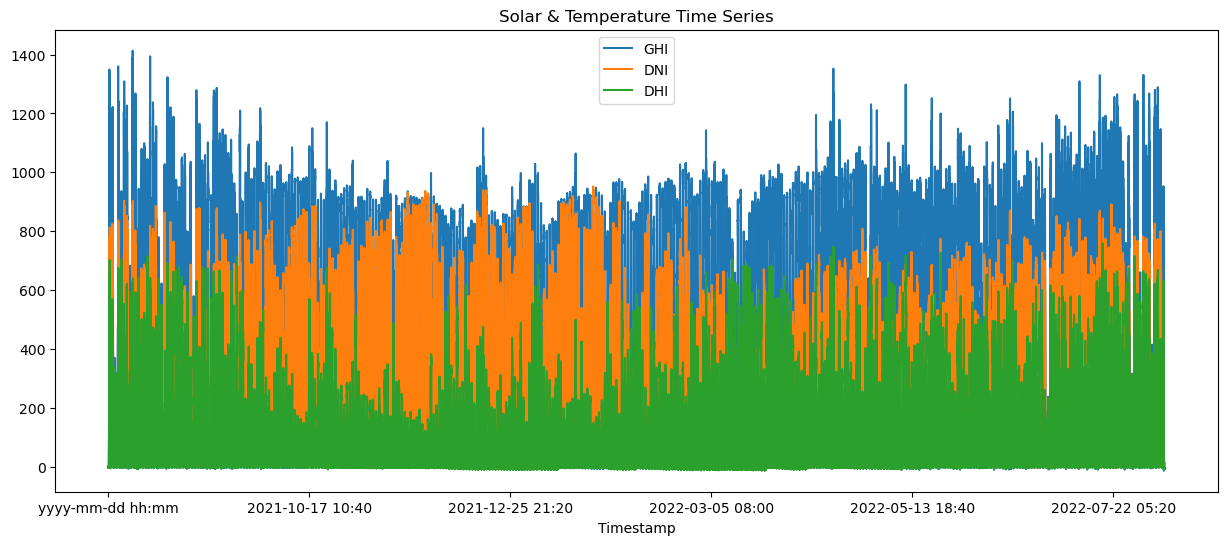

In [24]:
import matplotlib.pyplot as plt

df.set_index('Timestamp', inplace=True)
df[['GHI','DNI','DHI','Tamb']].plot(figsize=(15,6), title="Solar & Temperature Time Series")
plt.show()


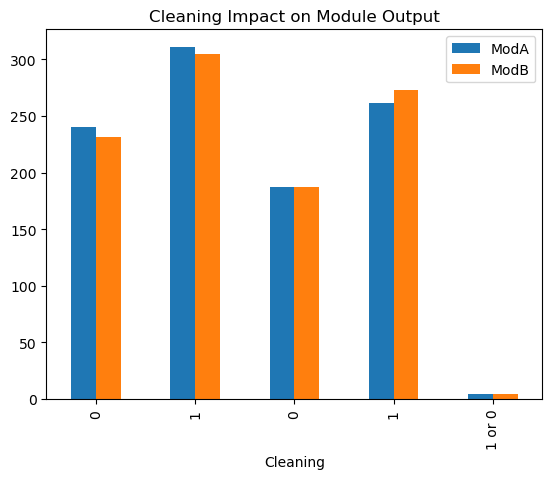

In [25]:
df.groupby('Cleaning')[['ModA','ModB']].mean().plot(kind='bar', title="Cleaning Impact on Module Output")
plt.show()


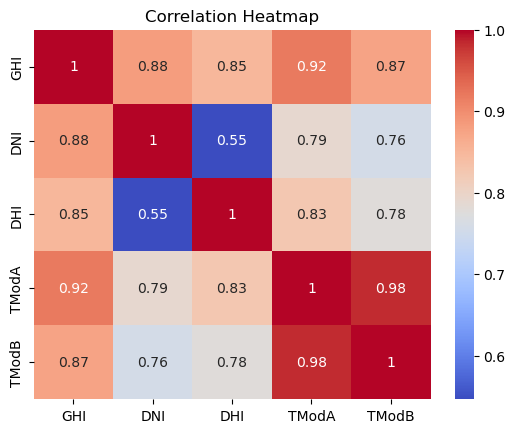

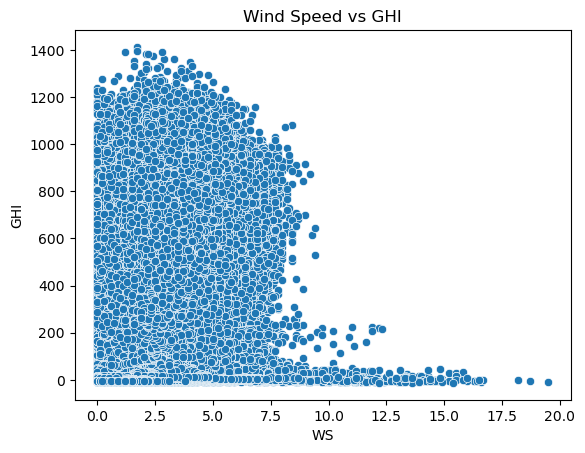

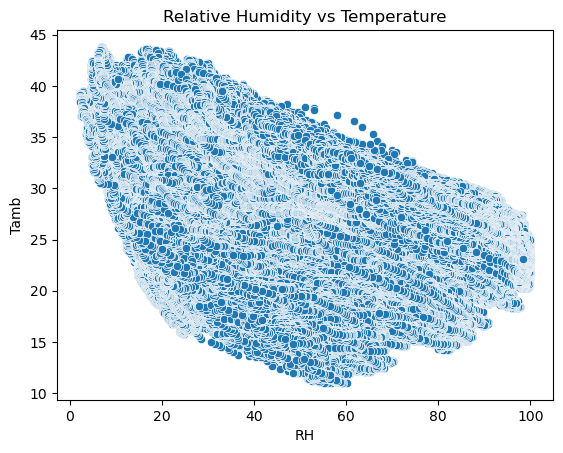

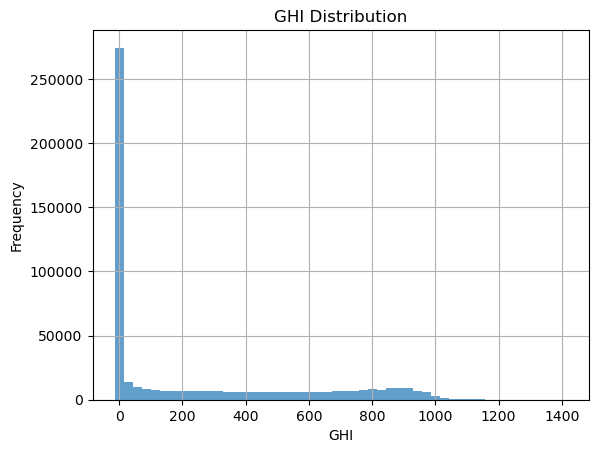

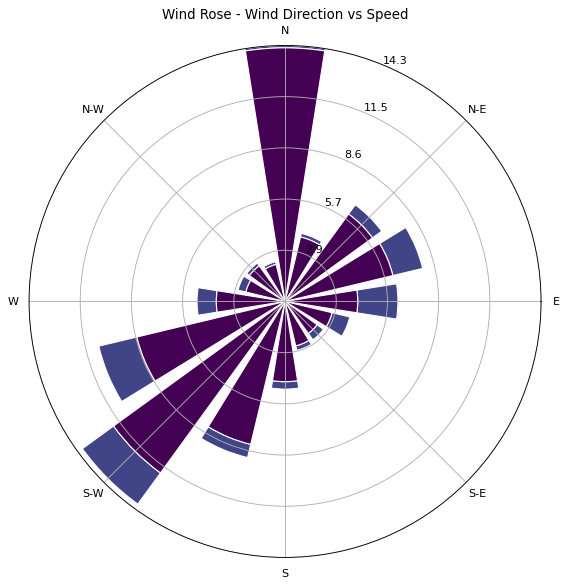

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Clean numeric columns (remove °C, %, etc.)
numeric_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'WS', 'WD', 'RH', 'Tamb']

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[^0-9.\-]', '', regex=True)  # keep digits, minus, decimal
        .replace('', np.nan)
        .astype(float)
    )

# ✅ Correlation heatmap
sns.heatmap(df[['GHI','DNI','DHI','TModA','TModB']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ✅ Scatter plots
sns.scatterplot(x='WS', y='GHI', data=df)
plt.title("Wind Speed vs GHI")
plt.show()

sns.scatterplot(x='RH', y='Tamb', data=df)
plt.title("Relative Humidity vs Temperature")
plt.show()

# ✅ Histogram
df['GHI'].hist(bins=50, alpha=0.7)
plt.title('GHI Distribution')
plt.xlabel('GHI')
plt.ylabel('Frequency')
plt.show()

# ✅ Wind rose plot
# Make sure windrose is installed
!pip install windrose

from windrose import WindroseAxes
ax = WindroseAxes.from_ax()
ax.bar(df['WD'], df['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_title('Wind Rose - Wind Direction vs Speed')
plt.show()


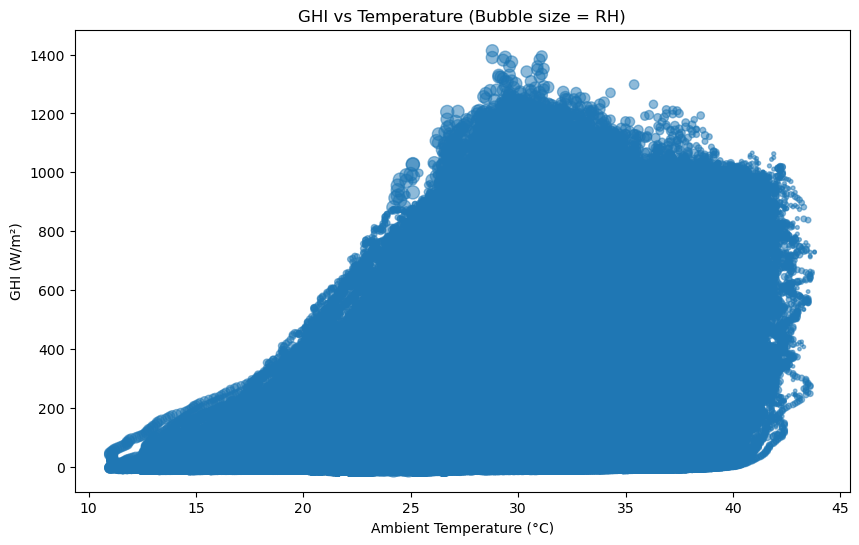

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(df['Tamb'], df['GHI'], s=df['RH'], alpha=0.5)
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("GHI (W/m²)")
plt.title("GHI vs Temperature (Bubble size = RH)")
plt.show()


In [32]:
clean_path = base_dir / "data" / "benin_clean.csv"
df.to_csv(clean_path, index=False)
print(f"✅ Cleaned file saved at: {clean_path}")


✅ Cleaned file saved at: c:\Users\Lamrot\Desktop\solar\solar-challenge-week0\data\benin_clean.csv
